## Iteration 2: Random Forest Modeling & Calibration (Home/Away 2+ Goals)

### Objective

- Train, tune, and calibrate Random Forest classifiers to predict both home and away team scoring 2+ goals.
- Optimize hyperparameters and probability thresholds for best F1-score.
- Assess calibration and export models for future use.

---

### Steps Performed

**1. Model Training & Hyperparameter Tuning**
- Used engineered dataset (`first_engineered_betting_features.csv`).
- Dropped leakage, redundant, and target columns via `cols_to_drop`.
- For both `target_home_plus_two` and `target_away_plus_two`:
  - Grid search over hyperparameters:
    - `n_estimators`: [100, 200]
    - `max_depth`: [None, 5, 10, 20]
    - `min_samples_split`: [2, 5, 10]
  - Scored on F1 with 3-fold cross-validation.

**2. Home 2+ Goals Model**
- Best RF params: `max_depth=5`, `min_samples_split=5`, `n_estimators=200`
- Best CV F1-score: **0.54**
- Test classification report (default threshold):
    - Class 0: precision 0.64, recall 0.77, f1 0.70
    - Class 1: precision 0.62, recall 0.46, f1 0.53
    - **Accuracy:** 0.64
- Best probability threshold for F1: **0.322**
    - F1-score at best threshold: 0.64
    - Precision: 0.50, Recall: 0.90
    - At optimal threshold, higher recall for positives (business value: catch more high-scoring games)
- Classification report (best threshold):
    - Class 0: precision 0.77, recall 0.28, f1 0.41
    - Class 1: precision 0.50, recall 0.90, f1 0.64
    - **Accuracy:** 0.56

**3. Away 2+ Goals Model**
- Best RF params: `max_depth=20`, `min_samples_split=5`, `n_estimators=100`
- Best CV F1-score: **0.35**
- Test classification report (default threshold):
    - Class 0: precision 0.71, recall 0.90, f1 0.80
    - Class 1: precision 0.52, recall 0.23, f1 0.32
    - **Accuracy:** 0.69
- Best probability threshold for F1: **0.267**
    - F1-score at best threshold: 0.52
    - Precision: 0.40, Recall: 0.75
    - At optimal threshold, increased recall for positives.

**4. Feature Importance & Threshold Analysis**
- Visualized top 20 feature importances for each model.
- Plotted precision, recall, and F1 vs. threshold to guide business-driven threshold selection.

**5. Probability Calibration**
- Plotted calibration curve (reliability diagram) for home 2+ goals model.
- **Brier score:** 0.2233 (lower = better calibration).
- Applied isotonic regression calibration:
    - Improved reliability of predicted probabilities.
    - Calibration curve plotted for both uncalibrated and calibrated models.

**6. Threshold Optimization (Post-Calibration)**
- Found optimal threshold for calibrated probabilities:
    - **Home 2+ Goals:** threshold 0.33, F1 0.64, precision 0.51, recall 0.86
    - Compared to uncalibrated threshold (0.32), F1 and recall similar, but calibration improved reliability.

**7. Model Export**
- Saved best Random Forest models and their feature lists for both targets:
    - `rf_target_home_plus_two_best.pkl`, `rf_target_home_plus_two_feature_list.pkl`
    - Ready for future scoring and business simulation.

---

### Results

- **Home/Away 2+ goals models** tuned for best business-driven F1-score and recall.
- **Probability calibration** improves reliability for downstream decision-making and strategy simulation.
- **Exported models and feature lists** ensure reproducibility and future evaluation.

---

In [31]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score, confusion_matrix
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, precision_recall_curve, auc
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import f1_score, precision_score, recall_score
from sklearn.calibration import calibration_curve
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import brier_score_loss
from imblearn.over_sampling import SMOTE
import joblib
import pickle
import xgboost as xgb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
pd.set_option('display.max_columns', None)

In [32]:
filePath = '../../data/processed/first_engineered_betting_features.csv'
df = pd.read_csv(filePath)
df

,Date,FTHG,FTAG,FTR,HTHG,HTAG,HTR,Referee,HS,AS,HST,AST,HC,AC,HF,AF,HY,AY,HR,AR,B365H,B365D,B365A,B365>2.5,B365<2.5,B365AHH,B365AHA,B365AH,VCH,VCD,VCA,BSH,BSD,BSA,BWH,BWD,BWA,GBH,GBD,GBA,GB>2.5,GB<2.5,GBAHH,GBAHA,GBAH,IWH,IWD,IWA,LBH,LBD,LBA,LBAHH,LBAHA,LBAH,PSH,PSD,PSA,P>2.5,P<2.5,PAHH,PAHA,SOH,SOD,SOA,SBH,SBD,SBA,SJH,SJD,SJA,WHH,WHD,WHA,Bb1X2,BbMxH,BbAvH,BbMxD,BbAvD,BbMxA,BbAvA,BbOU,BbMx>2.5,BbAv>2.5,BbMx<2.5,BbAv<2.5,BbAH,BbAHh,BbMxAHH,BbAvAHH,BbMxAHA,BbAvAHA,MaxH,MaxD,MaxA,AvgH,AvgD,AvgA,Max>2.5,Max<2.5,Avg>2.5,Avg<2.5,MaxAHH,MaxAHA,AvgAHH,AvgAHA,AHh,Season,Year,Month,DayOfWeek,TotalGoals,GoalsOver2_5,BTTS,Home_2plus,Away_2plus,HomeTeam_mean_FTHG,AwayTeam_mean_FTAG,HomeTeam,AwayTeam,HomeTeam_Arsenal,HomeTeam_Aston Villa,HomeTeam_Birmingham,HomeTeam_Blackburn,HomeTeam_Blackpool,HomeTeam_Bolton,HomeTeam_Bournemouth,HomeTeam_Brentford,HomeTeam_Brighton,HomeTeam_Burnley,HomeTeam_Cardiff,HomeTeam_Charlton,HomeTeam_Chelsea,HomeTeam_Crystal Palace,HomeTeam_Derby,HomeTeam_Everton,HomeTeam_Fulham,HomeTeam_Huddersfield,HomeTeam_Hull,HomeTeam_Leeds,HomeTeam_Leicester,HomeTeam_Liverpool,HomeTeam_Luton,HomeTeam_Man City,HomeTeam_Man United,HomeTeam_Middlesbrough,HomeTeam_Newcastle,HomeTeam_Norwich,HomeTeam_Nott'm Forest,HomeTeam_Portsmouth,HomeTeam_QPR,HomeTeam_Reading,HomeTeam_Sheffield United,HomeTeam_Southampton,HomeTeam_Stoke,HomeTeam_Sunderland,HomeTeam_Swansea,HomeTeam_Tottenham,HomeTeam_Watford,HomeTeam_West Brom,HomeTeam_West Ham,HomeTeam_Wigan,HomeTeam_Wolves,AwayTeam_Arsenal,AwayTeam_Aston Villa,AwayTeam_Birmingham,AwayTeam_Blackburn,AwayTeam_Blackpool,AwayTeam_Bolton,AwayTeam_Bournemouth,AwayTeam_Brentford,AwayTeam_Brighton,AwayTeam_Burnley,AwayTeam_Cardiff,AwayTeam_Charlton,AwayTeam_Chelsea,AwayTeam_Crystal Palace,AwayTeam_Derby,AwayTeam_Everton,AwayTeam_Fulham,AwayTeam_Huddersfield,AwayTeam_Hull,AwayTeam_Leeds,AwayTeam_Leicester,AwayTeam_Liverpool,AwayTeam_Luton,AwayTeam_Man City,AwayTeam_Man United,AwayTeam_Middlesbrough,AwayTeam_Newcastle,AwayTeam_Norwich,AwayTeam_Nott'm Forest,AwayTeam_Portsmouth,AwayTeam_QPR,AwayTeam_Reading,AwayTeam_Sheffield United,AwayTeam_Southampton,AwayTeam_Stoke,AwayTeam_Sunderland,AwayTeam_Swansea,AwayTeam_Tottenham,AwayTeam_Watford,AwayTeam_West Brom,AwayTeam_West Ham,AwayTeam_Wigan,AwayTeam_Wolves,HomeRecentGF,HomeRecentGA,HomeRecentPts,AwayRecentGF,AwayRecentGA,AwayRecentPts,h2h_home_wins_last5,home_league_position,away_league_position,position_diff,HomePts,AwayPts,HomeGoalDiff,AwayGoalDiff,HomeRecentGoalDiff,AwayRecentGoalDiff,RecentGoalDiff,HomeRecentShotsOnTarget,AwayRecentShotsOnTarget,RecentShotsOnTargetDiff,PosDiff,B365>2.5_missing,B365<2.5_missing,B365>2.5_implied_prob,B365<2.5_implied_prob,OddsMargin,OU_OddsMargin,OverUnderRatio,Weekend,EarlySeason,RefereeAggression,B365H_prob,B365D_prob,B365A_prob,B365H_prob_norm,B365D_prob_norm,B365A_prob_norm,cons_mean_home,cons_mean_draw,cons_mean_away,cons_min_home,cons_min_draw,cons_min_away,cons_max_home,cons_max_draw,cons_max_away,home_odds_spread,draw_odds_spread,away_odds_spread,B365_overround,cons_overround,cons_mean_over2.5,cons_mean_under2.5,cons_over2.5_prob,cons_under2.5_prob,mean_AH_home,mean_AH_away,market_AHh,target_home_plus_two,target_away_plus_two,home_away_odds_ratio
0,2002-08-27,5.0,2.0,H,3.0,0.0,H,P Durkin,10.0,8.0,8.0,6.0,1.0,1.0,9.0,9.0,3.0,2.0,0.0,0.0,1.17,5.50,13.00,1.867394,2.013934,1.953053,1.950898,-0.336141,2.850784,4.027811,4.935736,2.624982,3.753932,4.749475,2.732814,3.917273,4.548528,1.150000,6.500000,12.000000,1.847198,1.837633,1.89003,1.914697,-0.323485,1.20,5.00,10.00,1.200000,5.000000,11.000000,1.931357,1.914883,-0.349454,2.958986,4.266214,4.992703,1.856226,2.157956,1.967555,1.955565,1.18000,6.000000,13.000000,1.170000,5.500000,13.000000,2.619415,3.778735,4.686697,1.16,5.50,12.00,41.0,2.940935,2.722174,4.173095,3.880495,5.45658,4.757603,36.5166,2.003017,1.902307,2.033331,1.930361,23.13209,-0.303451,2.004782,1.93259,2.173407,2.071169,3.1928,4.493388,5.08369,3.003213,4.243009,4.610582,1.890303,2.207561,1.821665,2.


=== Evaluating target_home_plus_two ===
Fitting 3 folds for each of 24 candidates, totalling 72 fits
Best RF parameters: {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 200}
Best CV F1-score: 0.5395813887979176
Classification report (best RF grid search):
              precision    recall  f1-score   support

           0       0.64      0.77      0.70       876
           1       0.62      0.46      0.53       705

    accuracy                           0.64      1581
   macro avg       0.63      0.62      0.62      1581
weighted avg       0.63      0.64      0.63      1581


Best threshold for F1: 0.322
F1-score at best threshold: 0.643
Precision at best threshold: 0.501
Recall at best threshold: 0.898

Classification report (best F1 threshold):
              precision    recall  f1-score   support

           0       0.77      0.28      0.41       876
           1       0.50      0.90      0.64       705

    accuracy                           0.56      1581
   macro avg  

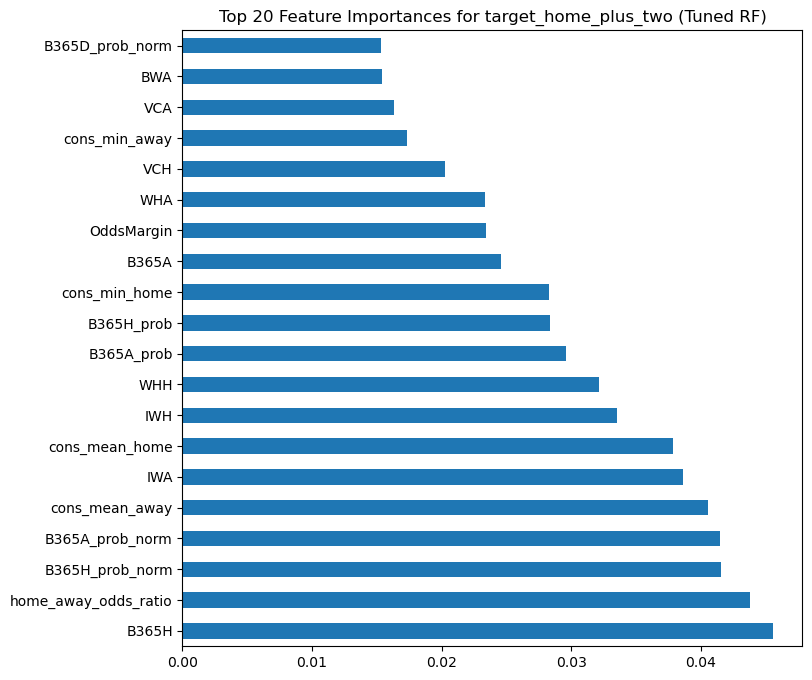

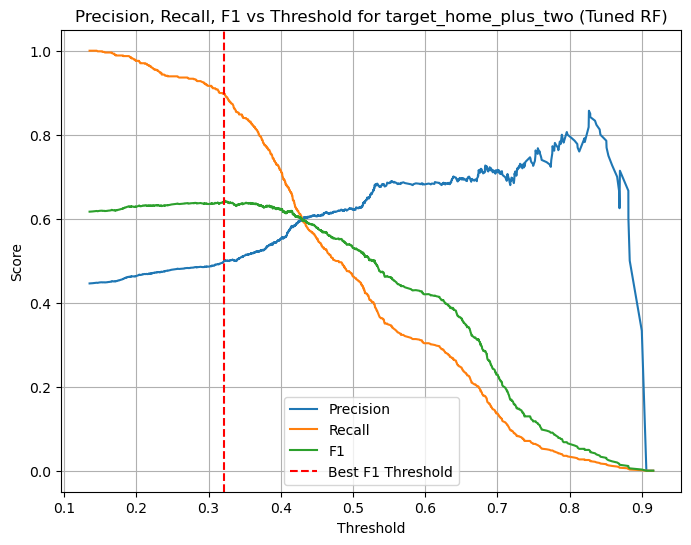


=== Evaluating target_away_plus_two ===
Fitting 3 folds for each of 24 candidates, totalling 72 fits
Best RF parameters: {'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 100}
Best CV F1-score: 0.34745959891209227
Classification report (best RF grid search):
              precision    recall  f1-score   support

           0       0.71      0.90      0.80      1075
           1       0.52      0.23      0.32       506

    accuracy                           0.69      1581
   macro avg       0.62      0.56      0.56      1581
weighted avg       0.65      0.69      0.64      1581


Best threshold for F1: 0.267
F1-score at best threshold: 0.523
Precision at best threshold: 0.403
Recall at best threshold: 0.747

Classification report (best F1 threshold):
              precision    recall  f1-score   support

           0       0.80      0.48      0.60      1075
           1       0.40      0.75      0.52       506

    accuracy                           0.56      1581
   macro avg

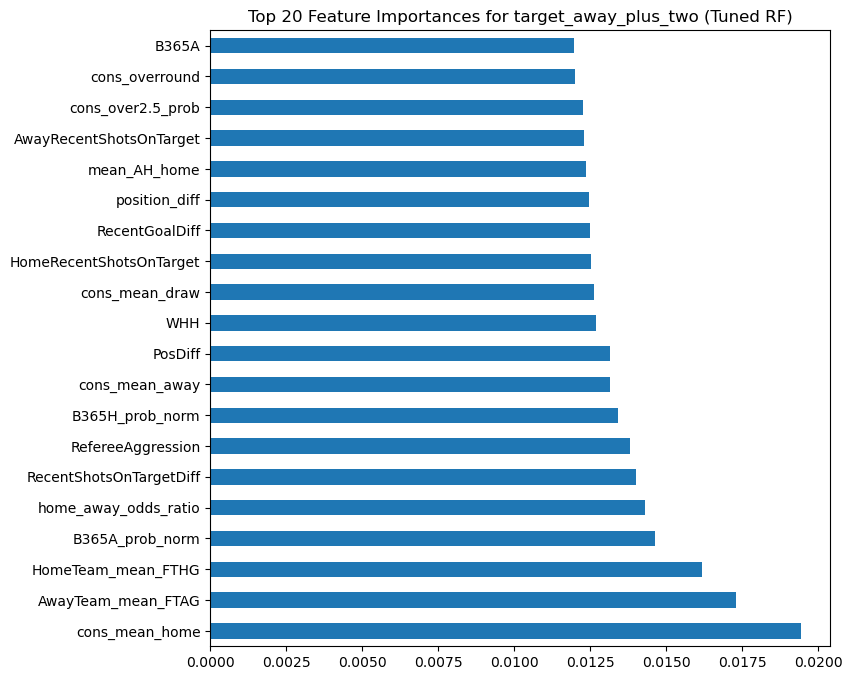

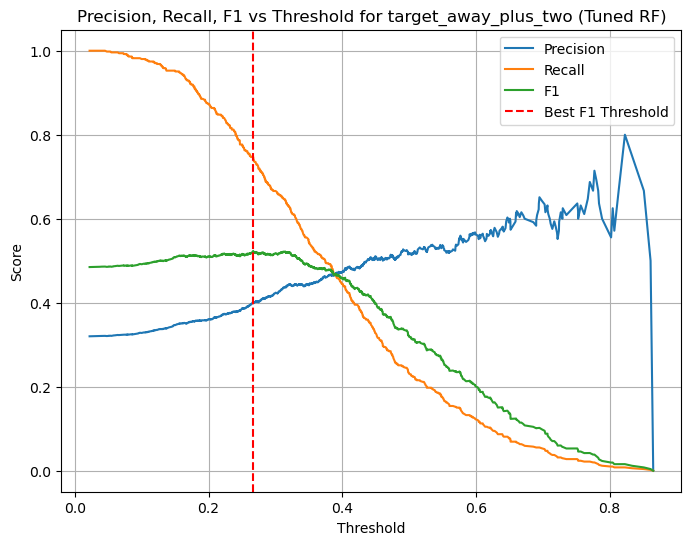

In [33]:
cols_to_drop = [
    'GoalsOver2_5', 'TotalGoals', 'FTHG', 'FTAG',
    'HTHG', 'HTAG',
    'HS', 'AS', 'HST', 'AST',
    'HC', 'AC',
    'HF', 'AF',
    'HY', 'AY',
    'HR', 'AR',
    'FTR_H', 'FTR_A', 'FTR_D',
    'HTR_H', 'HTR_A', 'HTR_D',
    'FTR', 'HTR',
    'HomeTeam', 'AwayTeam',
    'Date', 'Referee',
    'Season',
    'HomeGoalDiff', 'AwayGoalDiff',
    'HomePts', 'AwayPts',
    'BTTS', 'Home_2plus', 'Away_2plus',
    'target_home_plus_two', 'target_away_plus_two'
]

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10]
}

for target_col in ['target_home_plus_two', 'target_away_plus_two']:
    print(f"\n=== Evaluating {target_col} ===")
    X = df.drop(columns=cols_to_drop, errors='ignore')
    y = df[target_col]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    grid_search = GridSearchCV(
        RandomForestClassifier(random_state=42),
        param_grid,
        cv=3,
        scoring='f1',
        n_jobs=-1,
        verbose=2
    )
    grid_search.fit(X_train, y_train)

    print("Best RF parameters:", grid_search.best_params_)
    print("Best CV F1-score:", grid_search.best_score_)

    best_rf = grid_search.best_estimator_
    y_pred_grid = best_rf.predict(X_test)
    print("Classification report (best RF grid search):")
    print(classification_report(y_test, y_pred_grid))

    y_probs_grid = best_rf.predict_proba(X_test)[:, 1]
    precision, recall, thresholds = precision_recall_curve(y_test, y_probs_grid)
    f1 = 2 * (precision * recall) / (precision + recall + 1e-8)
    best_idx = np.argmax(f1[:-1])
    best_threshold = thresholds[best_idx]
    print(f"\nBest threshold for F1: {best_threshold:.3f}")
    print(f"F1-score at best threshold: {f1[best_idx]:.3f}")
    print(f"Precision at best threshold: {precision[best_idx]:.3f}")
    print(f"Recall at best threshold: {recall[best_idx]:.3f}")

    y_pred_best = (y_probs_grid >= best_threshold).astype(int)
    print("\nClassification report (best F1 threshold):")
    print(classification_report(y_test, y_pred_best))

    feat_importances = pd.Series(best_rf.feature_importances_, index=X.columns)
    feat_importances.nlargest(20).plot(kind='barh', figsize=(8, 8))
    plt.title(f'Top 20 Feature Importances for {target_col} (Tuned RF)')
    plt.show()

    plt.figure(figsize=(8,6))
    plt.plot(thresholds, precision[:-1], label='Precision')
    plt.plot(thresholds, recall[:-1], label='Recall')
    plt.plot(thresholds, f1[:-1], label='F1')
    plt.axvline(best_threshold, color='r', linestyle='--', label='Best F1 Threshold')
    plt.xlabel('Threshold')
    plt.ylabel('Score')
    plt.title(f'Precision, Recall, F1 vs Threshold for {target_col} (Tuned RF)')
    plt.legend()
    plt.grid()
    plt.show()

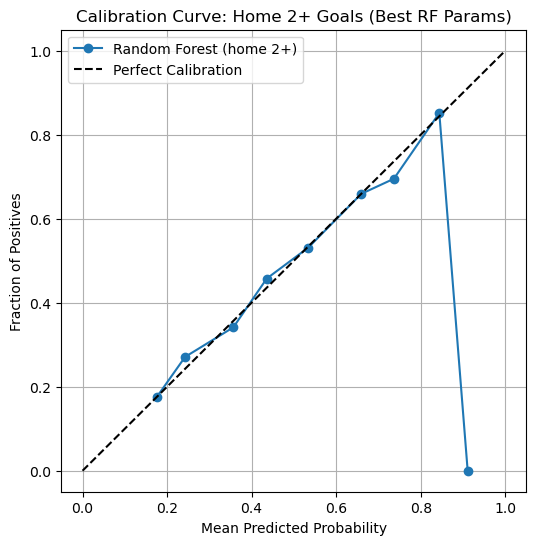

In [34]:
X = df.drop(columns=cols_to_drop, errors='ignore')
y = df['target_home_plus_two']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

best_rf = RandomForestClassifier(
    max_depth=5,
    min_samples_split=5,
    n_estimators=200,
    random_state=42
)
best_rf.fit(X_train, y_train)

y_probs = best_rf.predict_proba(X_test)[:, 1]

prob_true, prob_pred = calibration_curve(y_test, y_probs, n_bins=10, strategy='uniform')

plt.figure(figsize=(6,6))
plt.plot(prob_pred, prob_true, marker='o', label='Random Forest (home 2+)')
plt.plot([0,1], [0,1], 'k--', label='Perfect Calibration')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.title('Calibration Curve: Home 2+ Goals (Best RF Params)')
plt.legend()
plt.grid()
plt.show()

In [35]:
print("Mean predicted probabilities:", prob_pred)
print("Fraction of positives:", prob_true)

Mean predicted probabilities: [0.17546759 0.2425971  0.35666083 0.43581161 0.5335052  0.65946715
 0.7365984  0.84395165 0.9110583 ]
Fraction of positives: [0.17525773 0.27096774 0.34134615 0.45758355 0.53080569 0.65921788
 0.6952381  0.85185185 0.        ]


In [36]:
brier = brier_score_loss(y_test, y_probs)
print(f"Brier score (home 2+): {brier:.4f}")

Brier score (home 2+): 0.2233


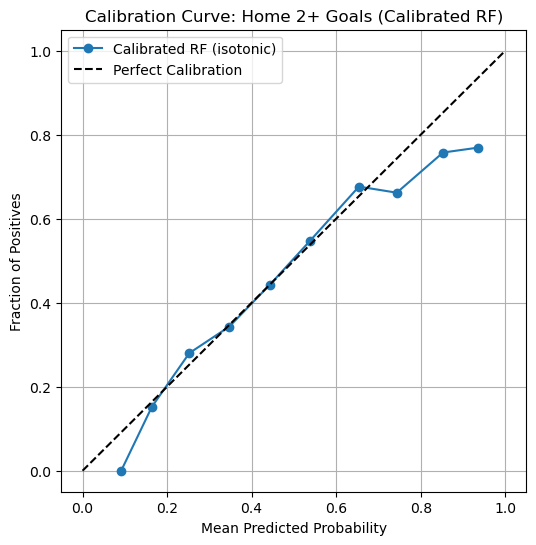

In [37]:
X = df.drop(columns=cols_to_drop, errors='ignore')
y = df['target_home_plus_two']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

base_rf = RandomForestClassifier(
    max_depth=5,
    min_samples_split=5,
    n_estimators=200,
    random_state=42
)
base_rf.fit(X_train, y_train)

calibrator = CalibratedClassifierCV(base_rf, method='isotonic', cv=5)
calibrator.fit(X_train, y_train)

y_probs_cal = calibrator.predict_proba(X_test)[:, 1]

prob_true_cal, prob_pred_cal = calibration_curve(y_test, y_probs_cal, n_bins=10, strategy='uniform')

plt.figure(figsize=(6,6))
plt.plot(prob_pred_cal, prob_true_cal, marker='o', label='Calibrated RF (isotonic)')
plt.plot([0,1], [0,1], 'k--', label='Perfect Calibration')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.title('Calibration Curve: Home 2+ Goals (Calibrated RF)')
plt.legend()
plt.grid()
plt.show()

In [38]:
print("Mean predicted probabilities (calibrated):", prob_pred_cal)
print("Fraction of positives (calibrated):", prob_true_cal)

Mean predicted probabilities (calibrated): [0.09142191 0.16403265 0.25256755 0.34693915 0.44359177 0.53720507
 0.65374643 0.74336316 0.85272238 0.93526705]
Fraction of positives (calibrated): [0.         0.15217391 0.28       0.34293948 0.44337349 0.54634146
 0.67647059 0.66197183 0.75757576 0.76923077]


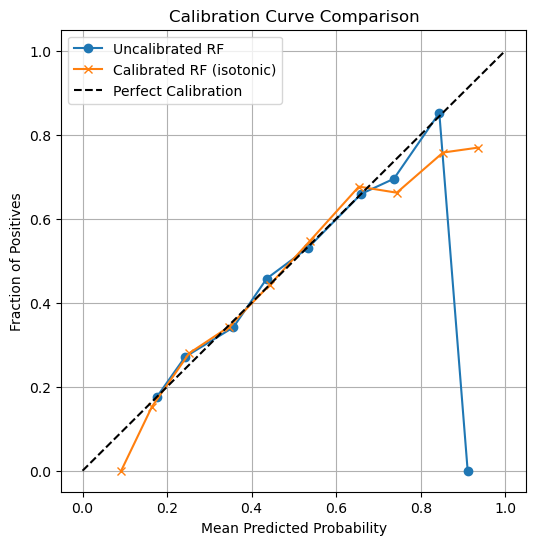

In [39]:
y_probs_uncal = base_rf.predict_proba(X_test)[:, 1]
prob_true_uncal, prob_pred_uncal = calibration_curve(y_test, y_probs_uncal, n_bins=10, strategy='uniform')

plt.figure(figsize=(6,6))
plt.plot(prob_pred_uncal, prob_true_uncal, marker='o', label='Uncalibrated RF')
plt.plot(prob_pred_cal, prob_true_cal, marker='x', label='Calibrated RF (isotonic)')
plt.plot([0,1], [0,1], 'k--', label='Perfect Calibration')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.title('Calibration Curve Comparison')
plt.legend()
plt.grid()
plt.show()

In [40]:
print("Mean predicted probabilities (uncalibrated):", prob_pred_uncal)
print("Fraction of positives (uncalibrated):", prob_true_uncal)

print("Mean predicted probabilities (calibrated):", prob_pred_cal)
print("Fraction of positives (calibrated):", prob_true_cal)

Mean predicted probabilities (uncalibrated): [0.17546759 0.2425971  0.35666083 0.43581161 0.5335052  0.65946715
 0.7365984  0.84395165 0.9110583 ]
Fraction of positives (uncalibrated): [0.17525773 0.27096774 0.34134615 0.45758355 0.53080569 0.65921788
 0.6952381  0.85185185 0.        ]
Mean predicted probabilities (calibrated): [0.09142191 0.16403265 0.25256755 0.34693915 0.44359177 0.53720507
 0.65374643 0.74336316 0.85272238 0.93526705]
Fraction of positives (calibrated): [0.         0.15217391 0.28       0.34293948 0.44337349 0.54634146
 0.67647059 0.66197183 0.75757576 0.76923077]


In [41]:
thresholds = np.linspace(0, 1, 101)
f1_scores = [f1_score(y_test, y_probs_cal > t) for t in thresholds]
optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx]

y_pred_opt = y_probs_cal > optimal_threshold
f1 = f1_score(y_test, y_pred_opt)
precision = precision_score(y_test, y_pred_opt)
recall = recall_score(y_test, y_pred_opt)

print(f"Optimal threshold (post-calibration): {optimal_threshold:.2f}")
print(f"F1 Score (post-calibration): {f1:.3f}")
print(f"Precision (post-calibration): {precision:.3f}")
print(f"Recall (post-calibration): {recall:.3f}")

Optimal threshold (post-calibration): 0.33
F1 Score (post-calibration): 0.638
Precision (post-calibration): 0.508
Recall (post-calibration): 0.860


In [42]:
f1_un = [f1_score(y_test, y_probs_uncal > t) for t in thresholds]
optimal_idx_un = np.argmax(f1_un)
optimal_threshold_un = thresholds[optimal_idx_un]

y_pred_opt_un = y_probs_uncal > optimal_threshold_un
f1_un_val = f1_score(y_test, y_pred_opt_un)
precision_un = precision_score(y_test, y_pred_opt_un)
recall_un = recall_score(y_test, y_pred_opt_un)

print(f"Optimal threshold (uncalibrated): {optimal_threshold_un:.2f}")
print(f"F1 Score (uncalibrated): {f1_un_val:.3f}")
print(f"Precision (uncalibrated): {precision_un:.3f}")
print(f"Recall (uncalibrated): {recall_un:.3f}")

Optimal threshold (uncalibrated): 0.32
F1 Score (uncalibrated): 0.639
Precision (uncalibrated): 0.496
Recall (uncalibrated): 0.898


In [43]:
target_col = "target_home_plus_two"
X_train = df.drop(columns=[target_col])
feature_list = X_train.columns.tolist()

model_filename = f"rf_{target_col}_best.pkl"
joblib.dump(best_rf, model_filename)

feature_list_filename = f"rf_{target_col}_feature_list.pkl"
joblib.dump(feature_list, feature_list_filename)

print(f"Saved best RF model for {target_col} to {model_filename}")
print(f"Saved feature list for {target_col} to {feature_list_filename}")

Saved best RF model for target_home_plus_two to rf_target_home_plus_two_best.pkl
Saved feature list for target_home_plus_two to rf_target_home_plus_two_feature_list.pkl
